# Modelatge
En aquest notebook aplicarem models d'aprenentatge no supervisats de clustering per agrupar els barris segons les seves característiques. 

**to do**
-  Preprocess
    - Log Transf\
Tal i com hem comentat en eda, algunes variables amb valor absoluts, presenten valors extrems. Per tal de reduir el seu efecte en clustering, aplicarem transformacions logarítmiques.
        - df_2015:
            - total_incidents_1000_hab
            - locals_restauracio_1000_hab
        - df_2023:
            - total_incidents_1000_hab
            - locals_serveis_professionals_1000_hab

    - Winsorization\
En relació als valors extrems esmentats anteriorment, els deltes calculats a partir d'aquests també queden exposats a aquest efecte. Dondad la naturalesa de les variacions (-inf, +inf) no podem aplicar transformació logarítmica directament. Per tant aplicarem tècnica de windsorization, per capar els valors extrems i imputar-los amb uns valors menys extrems (98%).
        - df_deltes
            - delta_locals_serveis_professionals_1000_hab
            - delta_pisos_turistics_1000_hab
            - delta_poblacio_total (tbc)
            - delta_pct_pob_estrangera
            - delta_locals_restauracio_1000_hab

-  StandardScaler
-  PCA
-  Models
    - Kmeans
    - AglomerativeClustering

- Conclusions i resultats

**Funcions a definir:**
- funcio per aplicar transf logarítmica a certes variables
- funcio per aplicar winsoring
- funcio per gràficar pca i variança explicada
- funcio per silouette i inercia
- funcio per kmeans i graficar clusters
- funcio per agglomerative i graficar clusters
- funcio per els clusters en mapa






# Llibreries i configuracio

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkt
import geopandas as gpd


# Evitar warning
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

from matplotlib.ticker import FixedLocator, FixedFormatter
sns.set_theme()

# Carrega dels datasets

In [4]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'
MIN = 2
MAX = 10

df_2015 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR / 'modelling' / 'df_deltes.csv')

dim_barris = pd.read_csv(DATA_DIR / 'dimensions' / 'BarcelonaCiutat_Barris.csv')

print("Dataset 2015: ", df_2015.shape)
print("Dataset 2023: ", df_2023.shape)
print("Dataset Deltes: ", df_deltes.shape)

Dataset 2015:  (73, 14)
Dataset 2023:  (73, 14)
Dataset Deltes:  (73, 14)


# Funcions auxiliars 

In [5]:
def transformacio_logaritmica(df: pd.DataFrame, columnes: list):
    df_mod = df.copy()
    for c in columnes:
        if (df_mod[c] < 0).any():
            raise ValueError(f"La columna {c} té valors negatius. No es pot aplicar log1p.")
        
        df_mod[c] = np.log1p(df_mod[c])
    return df_mod

def transformacio_winsor(df: pd.DataFrame, columnes: list, low: float, high: float):
    df_mod = df.copy()
    for c in columnes:
        lower = df_mod[c].quantile(low)
        upper = df_mod[c].quantile(high)
        
        df_mod[c] = df_mod[c].clip(lower, upper)
    
    return df_mod

def extreure_codi_barri(df:pd.DataFrame): 
    codi_barri = df["codi_barri"]
    X = df[[col for col in df.columns if col != "codi_barri"]].copy()
    return codi_barri, X


def grafic_var_explicada(pca: np.array, target: float, titol: str, nom_arxiu: str):
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= target) + 1
    var_explicada = pca.explained_variance_ratio_
    
    plt.figure(figsize=(6,3))
    plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, label="Var Explicada")
    plt.plot(range(1, len(var_explicada)+1), cumsum, linewidth=1, marker = 'o', label= "Var Explicada Cum",c ="r")
    plt.axhline(0.95, color='green', linestyle='--', label='95%')
    plt.plot([n_components, n_components], [0, target], "k:")
    plt.plot([0, n_components], [target, target], "k:")
    plt.plot(n_components, target, "ko")
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"{titol} | n_components = {n_components}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_arxiu}")
    plt.show()


def evaluate_kmeans(X:np.ndarray, min:int, max:int) -> dict:
    inercies = []
    silhouettes = []
    models = []
    for k in range(min, max):
        kmean = KMeans(n_clusters=k, n_init=20, random_state= 42).fit(X)
        models.append(kmean)
        inercies.append(kmean.inertia_)
        if len(models) > 1:
            silhouettes.append(silhouette_score(X, kmean.labels_))
    return {"models": models, "inercies": inercies, "silhouettes": silhouettes}


def consolidacio_resultats_seleccio_kmeans(resultats: dict)->pd.DataFrame:
    rows = []

    for tipus in ["pca", "escalades"]:
        for i, k in enumerate(resultats["n_clusters"]):
            rows.append({
                "n_clusters": k,
                "tipo_dades": tipus,
                "inercia": resultats[tipus]["inercies"][i],
                "silhouette": None if k == 1 else resultats[tipus]["silhouettes"][i - 1]
            })

    return pd.DataFrame(rows)

def plot_seleccio_kmeans(results_dict: dict, nom_dades: str, nom_fitxer: str) -> None:
    results = consolidacio_resultats_seleccio_kmeans(results_dict)
    fig = plt.figure(figsize=(8, 5))
    ax1 = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 1, 2)
    sns.lineplot(results, y = "inercia", x = "n_clusters", hue = "tipo_dades", ax=ax1, style="tipo_dades", markers=['o', 'D'])
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", ax= ax2, style="tipo_dades", markers = ['o', 'D'])
    plt.suptitle(f"Selecció de k amb KMeans ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

def plot_silhouettes(kmeans_per_k:list[KMeans], silhouette_scores: list[float], X:np.ndarray, nom_dades:str, nom_fitxer:str):
    plt.figure(figsize = (11,9))
    for k in (3, 4, 5, 6):
        plt.subplot(2, 2, k - 2)
        y_pred = kmeans_per_k[k - 1].labels_
        silhouette_coefficients = silhouette_samples(X, y_pred)

        padding = len(X) // 30
        pos = padding
        ticks = []
        for i in range(k):
            coeffs = silhouette_coefficients[y_pred == i]
            coeffs.sort()

            color = plt.cm.Spectral(i / k)
            plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                            facecolor=color, edgecolor=color, alpha=0.7)
            ticks.append(pos + len(coeffs) // 2)
            pos += len(coeffs) + padding

        plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
        plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
        if k in (3, 5):
            plt.ylabel("Cluster")
        
        if k in (5, 6):
            plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
            plt.xlabel("Silhouette Coefficient")
        else:
            plt.tick_params(labelbottom=False)

        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
        plt.title(f"$k={k}$")
    plt.suptitle(f"Coeficients de Silhouette per k ({nom_dades})")
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()


def plot_seleccio_agg(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    plt.figure(figsize=(8, 3))
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", style="tipo_dades", markers = ['o', 'D'])
    plt.title(f"Selecció de K amb Silhouette amb Agglomerative Clustering ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

def plot_clusters(df: pd.DataFrame, titol: str, nom_fitxer: str, dir: str=RESULTS_DIR):
    dim_barris["geometry"] = dim_barris["geometria_wgs84"].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(dim_barris, geometry="geometry", crs="EPSG:4326")
    gdf = gdf.merge(df[["codi_barri", "cluster"]], on="codi_barri", how="left")
    gdf.plot(
        column="cluster",
        categorical=True,
        legend=True,
        figsize=(8, 8),
        edgecolor="black",
        cmap="gist_rainbow",
        linewidth=0.3
    )
    plt.title(titol)
    plt.axis("off")
    plt.savefig(dir / f"{nom_fitxer}")
    plt.show()

def df_to_markdown(df):
    return pd.io.clipboards.to_clipboard(df.to_markdown(), excel=False)

# Preprocessament Comuns
- Separar variables de codi_barri
- Aplicar transformacions per outliers (logs o winsor)
- Escalar els conjunts de dades
- Aplicar PCA
- Aplicar clustering amb pca i amb escalat
- Seleccionar nombre de clusters
- Interpretació dels clústers

In [6]:
# Separem la columna de codi barri
codi_barri_15, X_15 = extreure_codi_barri(df_2015)
codi_barri_23, X_23 = extreure_codi_barri(df_2023)
codi_barri_deltes, X_deltes = extreure_codi_barri(df_deltes)

In [7]:
logs_2015 = ["total_incidents_1000_hab","locals_restauracio_1000_hab"]
logs_2023 = ["total_incidents_1000_hab", "locals_serveis_professionals_1000_hab"]
caps_deltes = [
    "delta_pct_pob_estrangera",
    "delta_pct_pob_estrangera_occidental",
    "delta_poblacio_total",
    "delta_locals_restauracio_1000_hab",
    "delta_locals_serveis_professionals_1000_hab",
    "delta_pisos_turistics_1000_hab",
    "delta_preu_mitja_m2",
    "delta_import_euros"
]


X_15_logs = transformacio_logaritmica(X_15, logs_2015)
X_23_logs = transformacio_logaritmica(X_23, logs_2023)
X_deltes_logs = transformacio_winsor(X_deltes, caps_deltes, 0.05, 0.95)

In [8]:
# Escalem les dades
scaler = StandardScaler()

X_15_scaled = scaler.fit_transform(X_15_logs)
X_23_scaled = scaler.fit_transform(X_23_logs)
X_deltes_scaled = scaler.fit_transform(X_deltes_logs)

# Dades 2015

## PCA (Principal Component analysis)

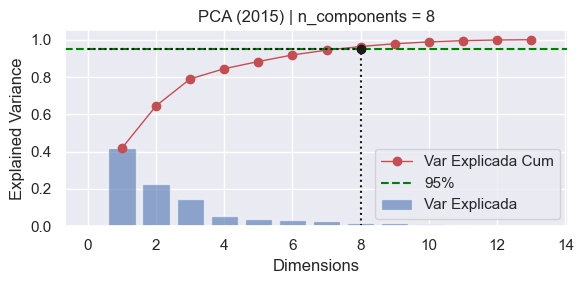

In [9]:
# Probarem PCA per reduir la dimensionalitat del conjunt de dades
pca_15 = PCA(random_state= 42)
pca_embedding = pca_15.fit_transform(X_15_scaled)
grafic_var_explicada(pca_15, 0.95, "PCA (2015)", "variança_explicada_15.png")

**Observacions:**
- 8 components per explicar el 95% de la variança de les dades. 
- Els tres principals components ja expliquen el 80% de la variança.

In [10]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_15 = np.argmax(np.cumsum(pca_15.explained_variance_ratio_) > 0.95) + 1

pca_15_fixed = PCA(n_components= n_components_15, random_state= 42)
X_pca_15_fixed = pca_15_fixed.fit_transform(X_15_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_15_fixed, columns=[f'PC{i}' for i in range(1, n_components_15 + 1)], index=df_2015['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.394009,4.551549,-1.515259,-2.319701,-0.199694,-0.956043,-0.042642,-0.262777
2,4.660526,6.204773,1.416379,-0.214522,-0.299504,0.124399,1.004626,-0.431889
3,2.745476,3.621419,1.370914,-0.257690,0.378690,-1.440013,1.603773,1.508977
4,4.263242,4.804871,0.842041,-0.365299,-0.335171,-1.050842,0.424999,-0.024162
5,1.967797,0.485187,-0.753469,0.790520,0.604716,0.161401,-0.657244,-0.241522


Tal i com s'observa a la gràfica anterior, el 80% de la variabilitat de les dades s' aconsegueix amb els 3 primers components principals. Per tal d' obtenir més detall procedirem a estudiar la composició d'aquests.

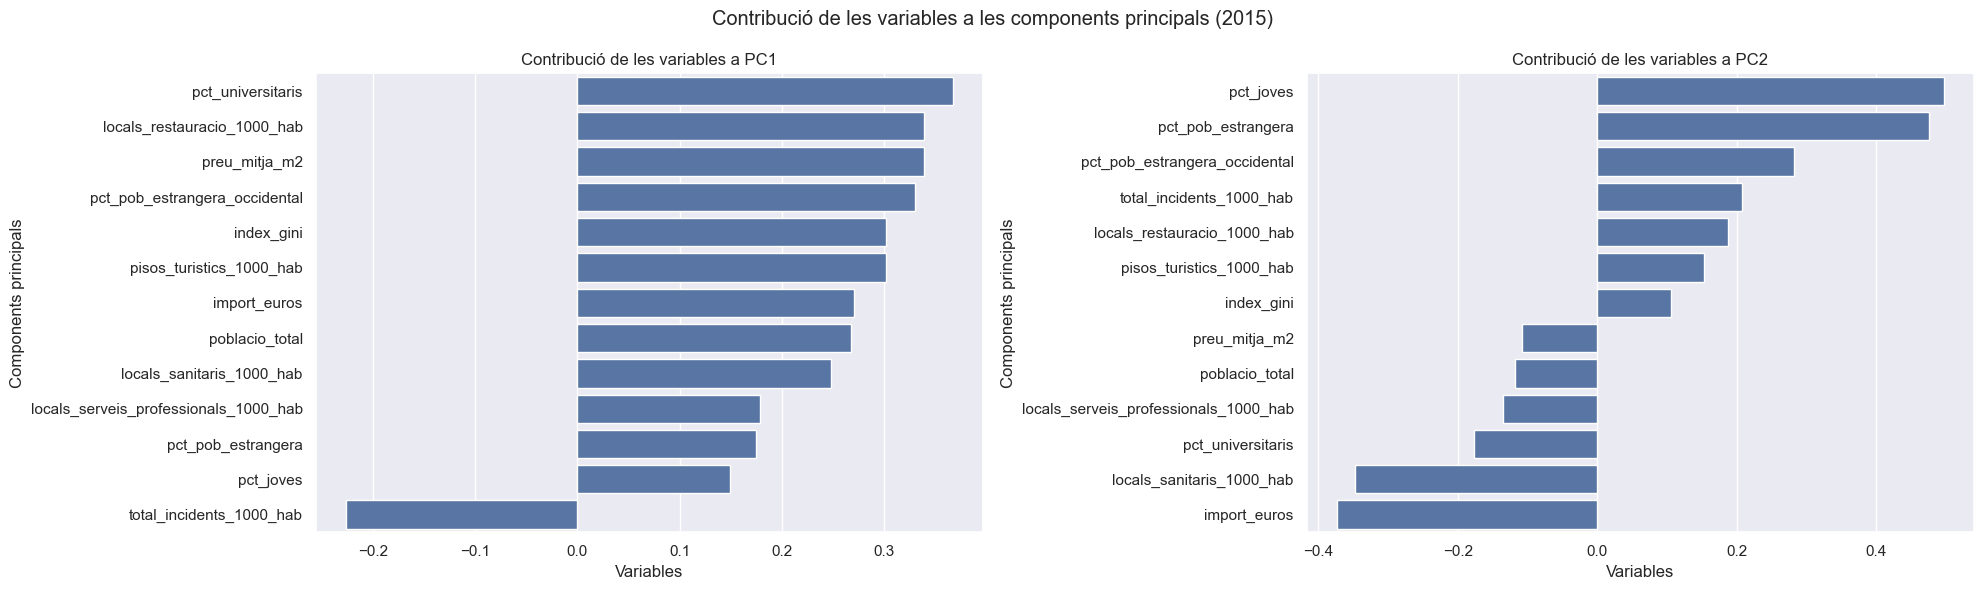

In [11]:
components_15 = pd.DataFrame(pca_15_fixed.components_[0:2], columns=X_15.columns, index=["PC1", "PC2"]).T.reset_index(names="atribut")


fig, axes = plt.subplots(figsize=(20, 6), nrows=1, ncols=2)
sns.barplot(data=components_15.sort_values("PC1", ascending=False), y="atribut", x="PC1",  ax=axes[0])
sns.barplot(data=components_15.sort_values("PC2", ascending=False), y="atribut", x="PC2", ax=axes[1])
plt.suptitle("Contribució de les variables a les components principals (2015)")
axes[0].set_title("Contribució de les variables a PC1")
axes[1].set_title("Contribució de les variables a PC2")
axes[0].set_xlabel("Variables")
axes[1].set_xlabel("Variables")
axes[0].set_ylabel("Components principals")
axes[1].set_ylabel("Components principals")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "contribucio_variables_pca_15.png")
plt.show()


**Observacions:**
- En el primer component (PC1) s'observen variables socioeconòmiques, urbanes i d'habitatge en que la seva presència té un efecte positiu. La variable amb més pes és pct_universitaris, seguida per locals de restauració i preu mitjà del lloguer. Per altra banda, els incidents tenen un pes negatiu en la construcció del component, és a dir, la seva absència és un valor important a l'hora de separar els barris. Aquest primer component capta doncs, variables de caràcter socoeonòmic, és a dir barris amb nivells d'estudis i rendes altes, enfocats a turisme i pressió immobiliaria.

- El segon component (PC2) captura variables de tipologia demogràfica i internacional. Les variables amb més pes són pct_joves, pct_pob_estrangera i pct_pob_estrangera_occidental. Per altra banda import_euros, locals_sanitaris_1000_hab i pct_universitaris tenen un pes alt i negatiu. En base a aquesta separació, podem dir que el component diferencia barris joves amb un fort component de població estrangera.

## KMeans

In [9]:
# Comparem clusters amb pca vs dades escalades
resultats_2015 = {}
resultats_2015["pca"] = evaluate_kmeans(X_pca_15_fixed, MIN, MAX)
resultats_2015["escalades"] = evaluate_kmeans(X_15_scaled, MIN, MAX)
resultats_2015["n_clusters"] = range(MIN, MAX)

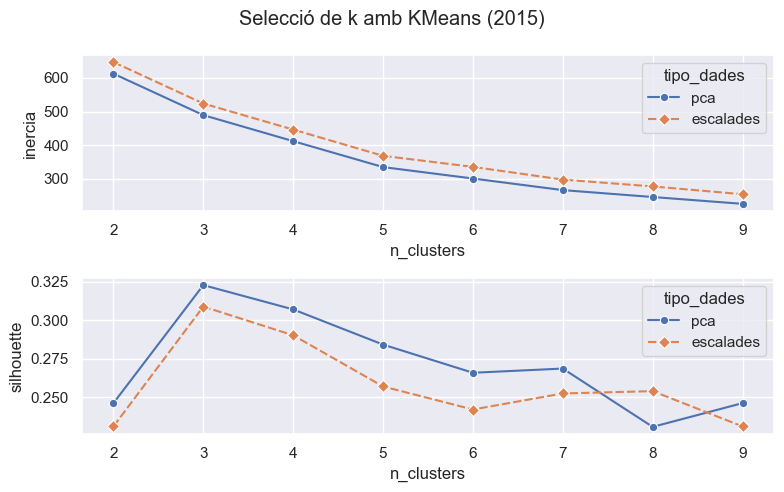

In [10]:
plot_seleccio_kmeans(resultats_2015, "2015", "seleccio_k_2015.png")

**Observacions:**
- El nombre òptim de clusters segons el valor de silhouette és 3, encara que amb 4 cluster s' obté un resultat força bai,x
- Els valors de silhouette són fluixos, indicant que els clusters no seran tant diferenciats.
- Els resultats milloren lleugerament amb pca.

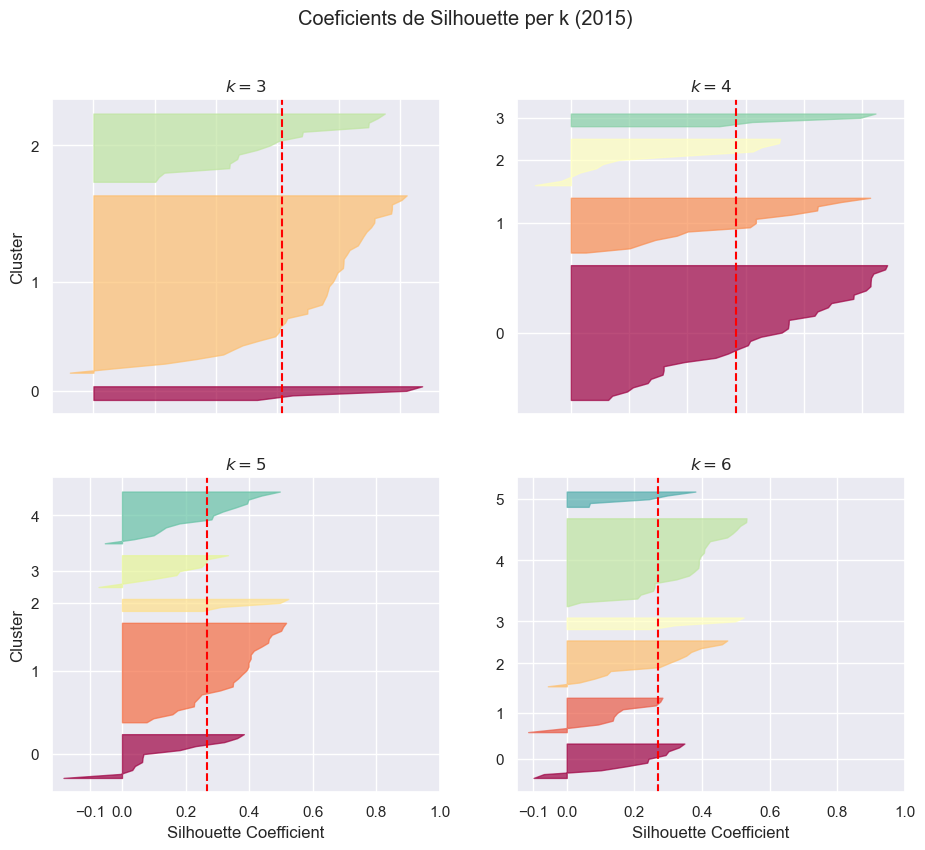

In [11]:
plot_silhouettes(resultats_2015["pca"]["models"], resultats_2015["pca"]["silhouettes"], X_pca_15_fixed, "2015", "silhouettes_2015.png")

**Observacions:**
- En concordància amb el que s' ha comentat anteriorment, els resultats de silhouette per a 3 i 4, són força bons.
- Amb k=3 els clusters estan força diferenciats, tots per sobre de la mitja. Pot ser adequat per interpretabilitat.
- Els resultats amb k=4 mostren una major separació de clustersm i ens podria donar més granularitat per a l'anàlisi dels clusters. També s' observa un cluster bastant petit i diferenciat en ambdós casos, segurament barris amb alta gentrificació.

## Decisió i conclusions

In [12]:
conclusions_df23 = {"clusters": "k=3", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "Tot i que k=3 és més simple i interpretable, k=4 ens permet diferenciar altres perfils de barris que amb k=3 queden barrejats."}

df_to_markdown(pd.DataFrame([conclusions_df23]))

## Clustering

In [13]:
# Apliquem kmeans
k_15 = 4
kmeans_15_final = KMeans(n_clusters= k_15, random_state= 42, n_init = 20)
kmeans_15_final_labels = kmeans_15_final.fit_predict(X_pca_15_fixed)

# Obtenim codi de barri i cluster
clustered = df_2015[["codi_barri"]].copy()
clustered['cluster'] = kmeans_15_final_labels
clustered.head()


,codi_barri,cluster
0,1,0
1,2,0
2,3,0
3,4,0
4,5,2


In [14]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered["cluster"].value_counts() )
print("\nPerfils: ")
perfils_15 = df_2015.merge(clustered, on = "codi_barri", how = "right")
perfils_15.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
1    40
2    16
3    13
0     4
Name: count, dtype: int64

Perfils: 


cluster,0,1,2,3
codi_barri,2.500000,46.800000,30.000000,26.076923
poblacio_total,25042.250000,15813.475000,35124.125000,23846.615385
pct_pob_estrangera,0.401387,0.133358,0.175897,0.126322
pct_pob_estrangera_occidental,0.162695,0.024349,0.065328,0.065280
pct_joves,0.399800,0.263827,0.295617,0.246601
pct_universitaris,0.264166,0.141535,0.287426,0.379472
import_euros,10615.768038,11779.621896,15063.089836,21017.075429
index_gini,37.973881,31.189503,33.908692,36.999989
total_incidents_1000_hab,30.457174,52.024721,18.134005,28.966433
locals_restauracio_1000_hab,19.001463,3.121797,7.177124,5.522285


In [15]:
df_to_markdown(perfils_15.groupby("cluster").mean().T)

|                                       |            0 |             1 |            2 |
|:--------------------------------------|-------------:|--------------:|-------------:|
| codi_barri                            |    27.7667   |    47.641     |     2.5      |
| poblacio_total                        | 29412.1      | 15953         | 25042.2      |
| pct_pob_estrangera                    |     0.154681 |     0.132063  |     0.401387 |
| pct_pob_estrangera_occidental         |     0.065206 |     0.0233761 |     0.162695 |
| pct_joves                             |     0.274368 |     0.263019  |     0.3998   |
| pct_universitaris                     |     0.325844 |     0.138924  |     0.264166 |
| import_euros                          | 17606.9      | 11723.3       | 10615.8      |
| index_gini                            |    35.2065   |    31.1519    |    37.9739   |
| total_incidents_1000_hab              |    23.3421   |    52.4983    |    30.4572   |
| locals_restauracio_1000_hab           |     6.33007  |     3.11778   |    19.0015   |
| locals_sanitaris_1000_hab             |     1.08571  |     0.409403  |     0.323594 |
| locals_serveis_professionals_1000_hab |     1.39396  |     0.828169  |     0.600092 |
| preu_mitja_m2                         |    11.8433   |     8.99231   |    12.825    |
| pisos_turistics_1000_hab              |     6.85932  |     0.607512  |     6.96934  |

In [16]:
barris_clusters_15 = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_15_merged = barris_clusters_15.merge(clustered, on = "codi_barri", how = "left")

for c in set(barris_clusters_15_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_15_merged["nom_barri"][barris_clusters_15_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['el Raval' 'el Barri Gòtic' 'la Barceloneta'
 'Sant Pere, Santa Caterina i la Ribera']
**************************************************

Barris en cluster 1:
['la Marina del Prat Vermell' 'la Marina de Port' 'la Font de la Guatlla'
 'la Bordeta' 'Sants - Badal' 'el Coll' 'Can Baró' "la Font d'en Fargues"
 'el Carmel' 'la Teixonera' 'Sant Genís dels Agudells' 'Montbau'
 "la Vall d'Hebron" 'la Clota' 'Horta' 'Vilapicina i la Torre Llobeta'
 'Porta' 'el Turó de la Peira' 'Can Peguera' 'la Guineueta' 'Canyelles'
 'les Roquetes' 'Verdun' 'la Prosperitat' 'la Trinitat Nova' 'Torre Baró'
 'Ciutat Meridiana' 'Vallbona' 'la Trinitat Vella' 'Baró de Viver'
 'el Bon Pastor' 'Sant Andreu' 'la Sagrera' 'el Congrés i els Indians'
 'Navas' 'el Clot' 'el Besòs i el Maresme' 'Provençals del Poblenou'
 'Sant Martí de Provençals' 'la Verneda i la Pau']
**************************************************

Barris en cluster 2:
['el Fort Pienc' 'la Sagrada Família' "l'Antiga Esquerra

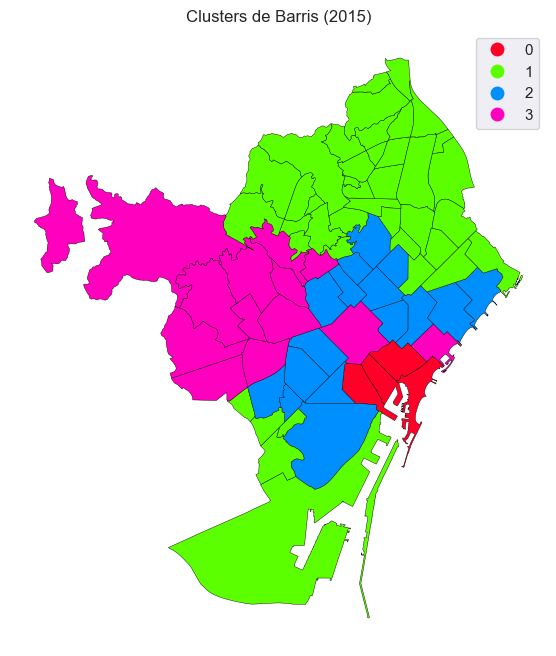

In [17]:
plot_clusters(clustered, "Clusters de Barris (2015)", "clusters_15.png")

In [18]:
perfils_15.to_csv(DATA_DIR / 'clustered' / 'df_2015.csv', index= False)

# Dades 2023

## PCA (Principal Component Analysisi)

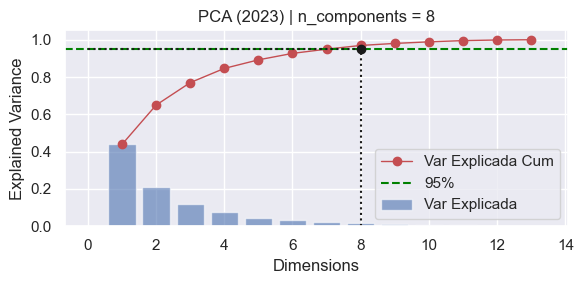

In [28]:
pca_23 = PCA(random_state= 42)
pca_embedding = pca_23.fit_transform(X_23_scaled)
grafic_var_explicada(pca_23, 0.95, "PCA (2023)", "variança_explicada_23.png")

**Observacions:**
- Per al dataset de 2023 el nombre de dimensions necessari per explicar el 95% de la variança són 8

In [29]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_23 = np.argmax(np.cumsum(pca_23.explained_variance_ratio_) > 0.95) + 1

pca_23_fixed = PCA(n_components= n_components_23, random_state= 42)
X_pca_23_fixed = pca_23_fixed.fit_transform(X_23_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_23_fixed, columns=[f'PC{i}' for i in range(1, n_components_23 + 1)], index=df_2023['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.279588,3.895755,0.532555,-1.569706,-0.439043,-0.896257,0.214921,-0.009310
2,4.617444,6.031876,-1.815871,-1.039161,-1.356210,-0.571358,0.530613,0.426491
3,3.060700,3.392185,-1.974732,0.106278,-0.163602,-0.581584,-1.488165,0.570237
4,4.674134,4.093708,-2.075445,-0.324293,-0.279745,-0.335467,-0.825599,-0.769719
5,2.118740,1.080636,0.494154,0.111880,0.864906,-0.080071,0.637641,-0.034132


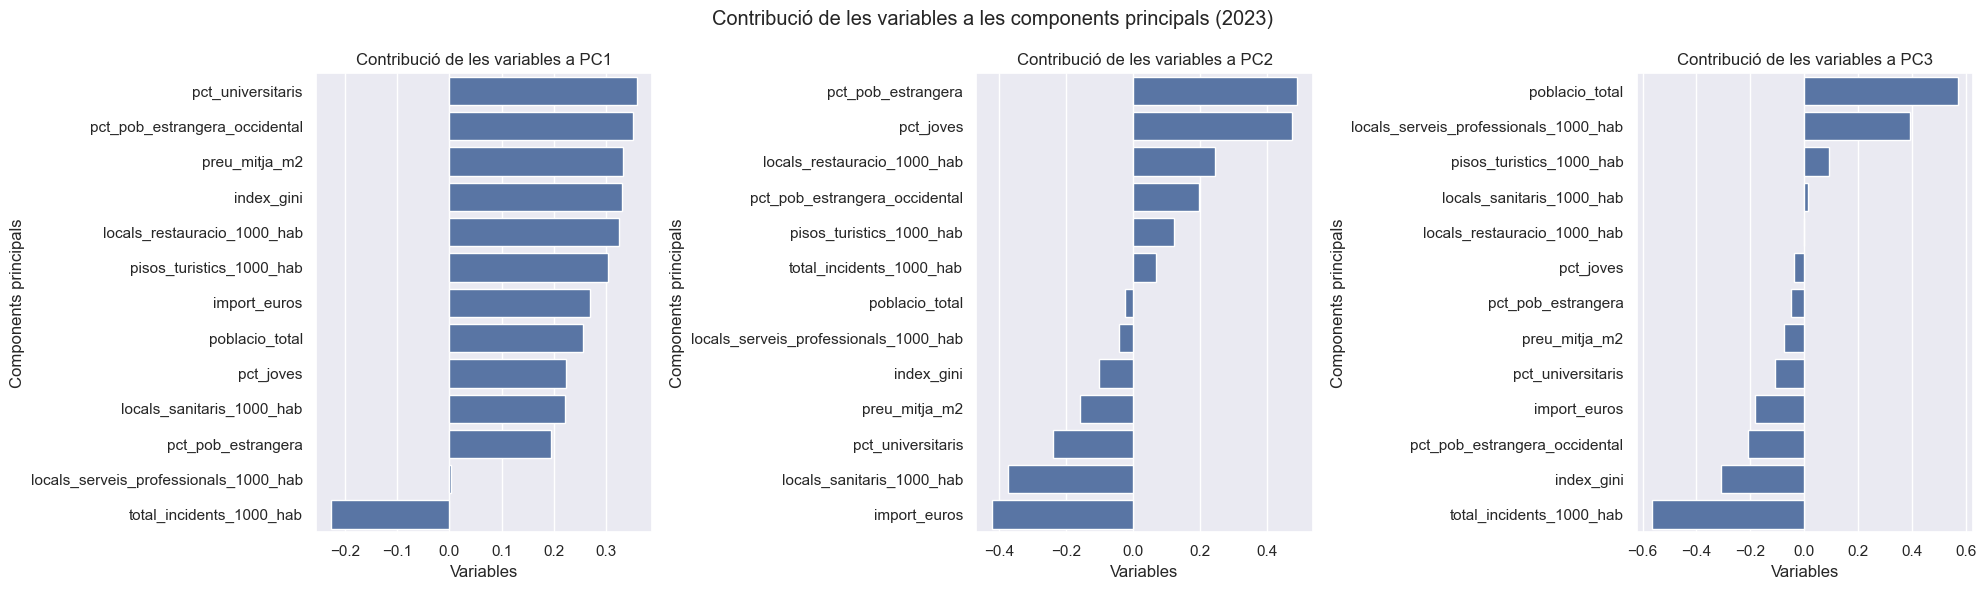

In [35]:
components_23 = pd.DataFrame(pca_23_fixed.components_[0:3], columns=X_23.columns, index=["PC1", "PC2", "PC3"]).T.reset_index(names="atribut")


fig, axes = plt.subplots(figsize=(20, 6), nrows=1, ncols=3)
sns.barplot(data=components_23.sort_values("PC1", ascending=False), y="atribut", x="PC1",  ax=axes[0])
sns.barplot(data=components_23.sort_values("PC2", ascending=False), y="atribut", x="PC2", ax=axes[1])
sns.barplot(data=components_23.sort_values("PC3", ascending=False), y="atribut", x="PC3", ax=axes[2])
plt.suptitle("Contribució de les variables a les components principals (2023)")
axes[0].set_title("Contribució de les variables a PC1")
axes[1].set_title("Contribució de les variables a PC2")
axes[2].set_title("Contribució de les variables a PC3")
axes[0].set_xlabel("Variables")
axes[1].set_xlabel("Variables")
axes[2].set_xlabel("Variables")
axes[0].set_ylabel("Components principals")
axes[1].set_ylabel("Components principals")
axes[2].set_ylabel("Components principals")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "contribucio_variables_pca_23.png")
plt.show()


**Observacions:**
- 

## KMeans

In [21]:
# Comparem clusters amb pca vs dades escalades
resultats_2023 = {}
resultats_2023["pca"] = evaluate_kmeans(X_pca_23_fixed, MIN, MAX)
resultats_2023["escalades"] = evaluate_kmeans(X_23_scaled, MIN, MAX)
resultats_2023["n_clusters"] = range(MIN, MAX)

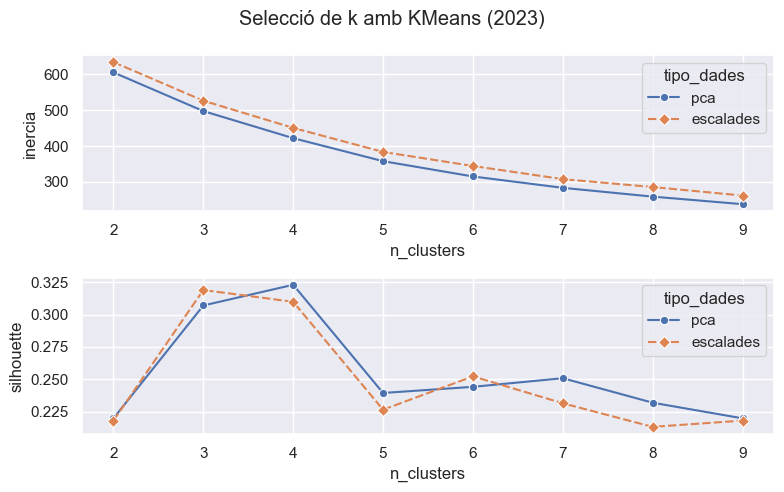

In [22]:
plot_seleccio_kmeans(resultats_2023, "2023", "seleccio_k_2023.png")

**Observacions:**
- Resultats força igualats. Per als dos mètodes, k=3 i k=4 són bons candidats. Per a les dades escalades, k=3 però per les dades amb pca aplicat k=4.
- Per practicitat i mantenir procés, utilitzarem dades amb pca aplicat.

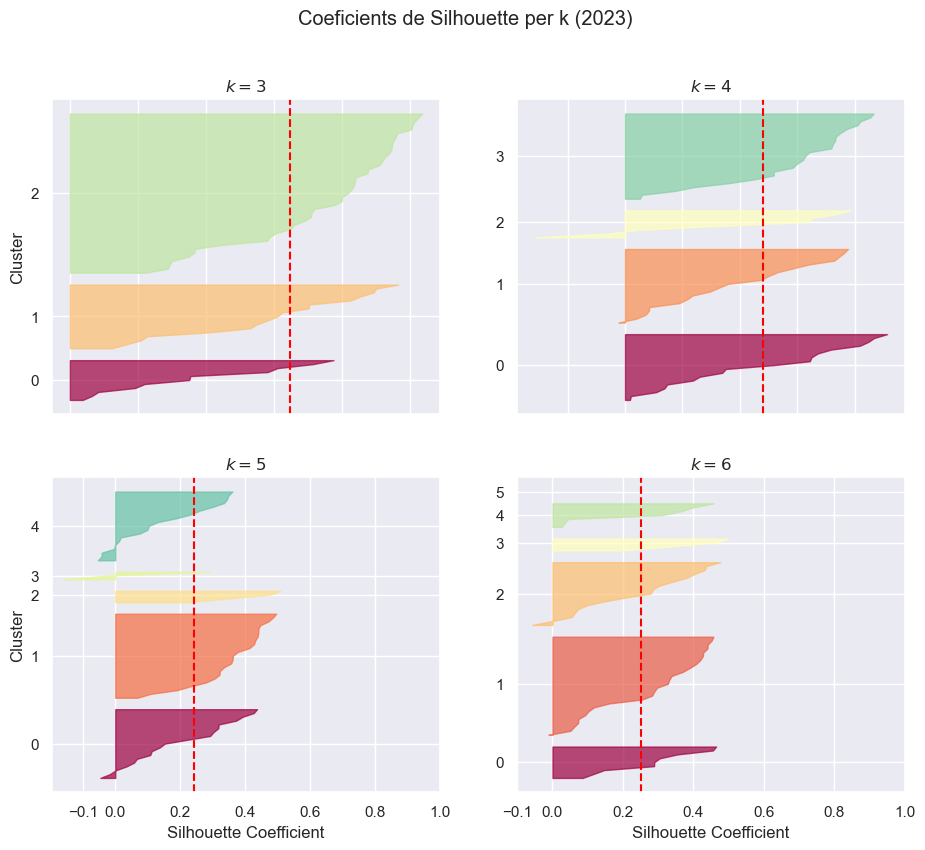

In [23]:
plot_silhouettes(resultats_2023["pca"]["models"], resultats_2023["pca"]["silhouettes"], X_pca_23_fixed, "2023", "silhouettes_2023.png")

**Observacions:**
- Els resultats mostren un patró similar al de les dades de 2015. k=3 ens serviria per una lectura més simple i k=4 ens permetria anar més al detall i separar més perfils de barris. 
- Un altre factor important a favor de k=4 és que presenta uns resultats de silhouette més alts, i per tant més qualitat de clustering.

## Decisió i conclusions

In [24]:
conclusions_df23 = {"clusters": "k=4", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "Segunt amb la conclusió de 2015, s’ha seleccionat una solució amb k=4 per una major diferenciació entre perfils urbans. "}

df_to_markdown(pd.DataFrame([conclusions_df23]))

## Clustering

In [25]:
# Apliquem kmeans
k_23 = 4
kmeans_23_final = KMeans(n_clusters= k_23, random_state= 42, n_init = 20)
kmeans_23_final_labels = kmeans_23_final.fit_predict(X_pca_23_fixed)

# Obtenim codi de barri i cluster
clustered_23 = df_2023[["codi_barri"]].copy()
clustered_23['cluster'] = kmeans_23_final_labels
clustered_23.head()


,codi_barri,cluster
0,1,3
1,2,3
2,3,3
3,4,3
4,5,1


In [26]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered_23["cluster"].value_counts() )
print("\nPerfils: ")
perfils_23 = df_2023.merge(clustered_23, on = "codi_barri", how = "right")
perfils_23.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
2    41
1    17
0    11
3     4
Name: count, dtype: int64

Perfils: 


cluster,0,1,2,3
codi_barri,24.090909,29.411765,46.975610,2.500000
poblacio_total,23798.090909,33861.352941,17477.243902,26611.500000
pct_pob_estrangera,0.167663,0.261791,0.193395,0.513533
pct_pob_estrangera_occidental,0.068589,0.098404,0.033155,0.164410
pct_joves,0.238383,0.300125,0.255152,0.428441
pct_universitaris,0.424067,0.378786,0.191487,0.307910
import_euros,27788.443303,20775.291378,15475.124632,14977.917610
index_gini,36.277946,32.458638,28.808701,35.660057
total_incidents_1000_hab,31.271162,23.409614,55.007708,30.318418
locals_restauracio_1000_hab,4.492983,8.847777,3.179713,14.723694


In [27]:
barris_clusters_23 = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_23_merged = barris_clusters_23.merge(clustered_23, on = "codi_barri", how = "left")

for c in set(barris_clusters_23_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_23_merged["nom_barri"][barris_clusters_23_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['les Corts' 'la Maternitat i Sant Ramon' 'Pedralbes'
 'Vallvidrera, el Tibidabo i les Planes' 'Sarrià' 'les Tres Torres'
 'Sant Gervasi - la Bonanova' 'Sant Gervasi - Galvany'
 'el Putxet i el Farró' 'Vallcarca i els Penitents' 'la Salut']
**************************************************

Barris en cluster 1:
['el Fort Pienc' 'la Sagrada Família' "la Dreta de l'Eixample"
 "l'Antiga Esquerra de l'Eixample" "la Nova Esquerra de l'Eixample"
 'Sant Antoni' 'el Poble-sec' 'la Font de la Guatlla' 'Hostafrancs'
 'Sants' 'la Vila de Gràcia' "el Camp d'en Grassot i Gràcia Nova"
 "el Camp de l'Arpa del Clot" 'el Parc i la Llacuna del Poblenou'
 'la Vila Olímpica del Poblenou' 'el Poblenou'
 'Diagonal Mar i el Front Marítim del Poblenou']
**************************************************

Barris en cluster 2:
['la Marina del Prat Vermell' 'la Marina de Port' 'la Bordeta'
 'Sants - Badal' 'el Coll' 'el Baix Guinardó' 'Can Baró' 'el Guinardó'
 "la Font d'en Fargues" 'el Ca

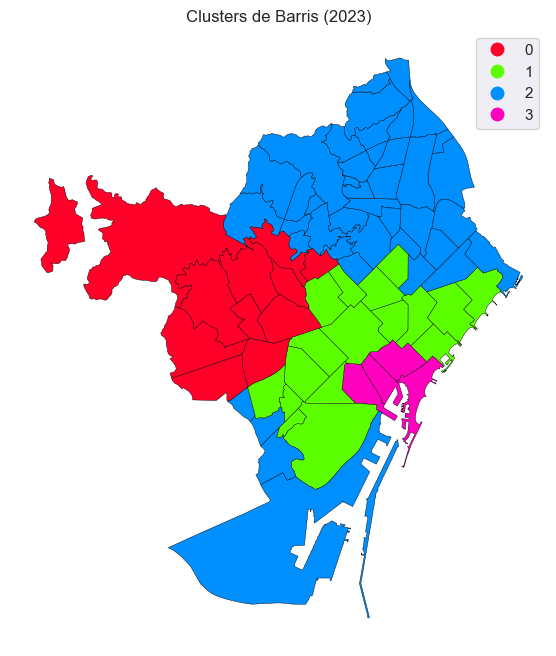

In [28]:
plot_clusters(clustered_23, "Clusters de Barris (2023)", "clusters_23.png")

In [29]:
df_to_markdown(perfils_23.groupby("cluster").mean().T)

In [30]:
perfils_23.to_csv(DATA_DIR / 'clustered' / 'df_2023.csv', index= False)

# Deltes

## PCA (Principal component analysis)

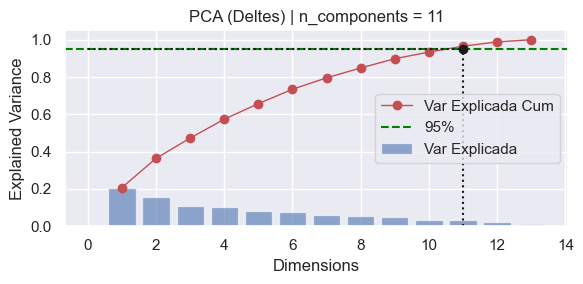

In [31]:
pca_deltes = PCA(random_state= 42)
pca_embedding = pca_deltes.fit_transform(X_deltes_scaled)
grafic_var_explicada(pca_deltes, 0.95, "PCA (Deltes)", "variança_explicada_deltes.png")

**Observacions:**
- Per al dataset de Deltes el nombre de dimensions necessari per explicar el 95% de la variança són 9 components

In [32]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_deltes = np.argmax(np.cumsum(pca_deltes.explained_variance_ratio_) > 0.95) + 1

pca_deltes_fixed = PCA(n_components= n_components_deltes, random_state= 42)
X_pca_deltes_fixed = pca_deltes_fixed.fit_transform(X_deltes_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_deltes_fixed, columns=[f'PC{i}' for i in range(1, n_components_deltes + 1)], index=df_deltes['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
codi_barri,,,,,,,,,,,
1,2.006969,-1.008362,0.183629,-1.561641,-0.604782,-0.399447,-0.944708,0.112463,0.341412,-0.818267,0.372416
2,-1.761039,0.341250,-2.403138,-4.761359,2.840067,0.416771,0.665730,-0.360289,-0.437948,-0.356956,0.968683
3,1.055024,0.080233,-1.462858,-1.033372,-0.405875,-0.125189,-1.640758,1.734090,1.530872,0.122266,0.474487
4,2.064010,-0.801158,-1.076321,-1.505479,-0.575442,-0.149068,-0.689053,0.757602,0.788324,-0.769931,0.337798
5,-1.035235,0.576406,-0.563705,-1.181013,0.335336,0.221969,1.158425,0.668984,-0.101123,-0.025662,0.038864


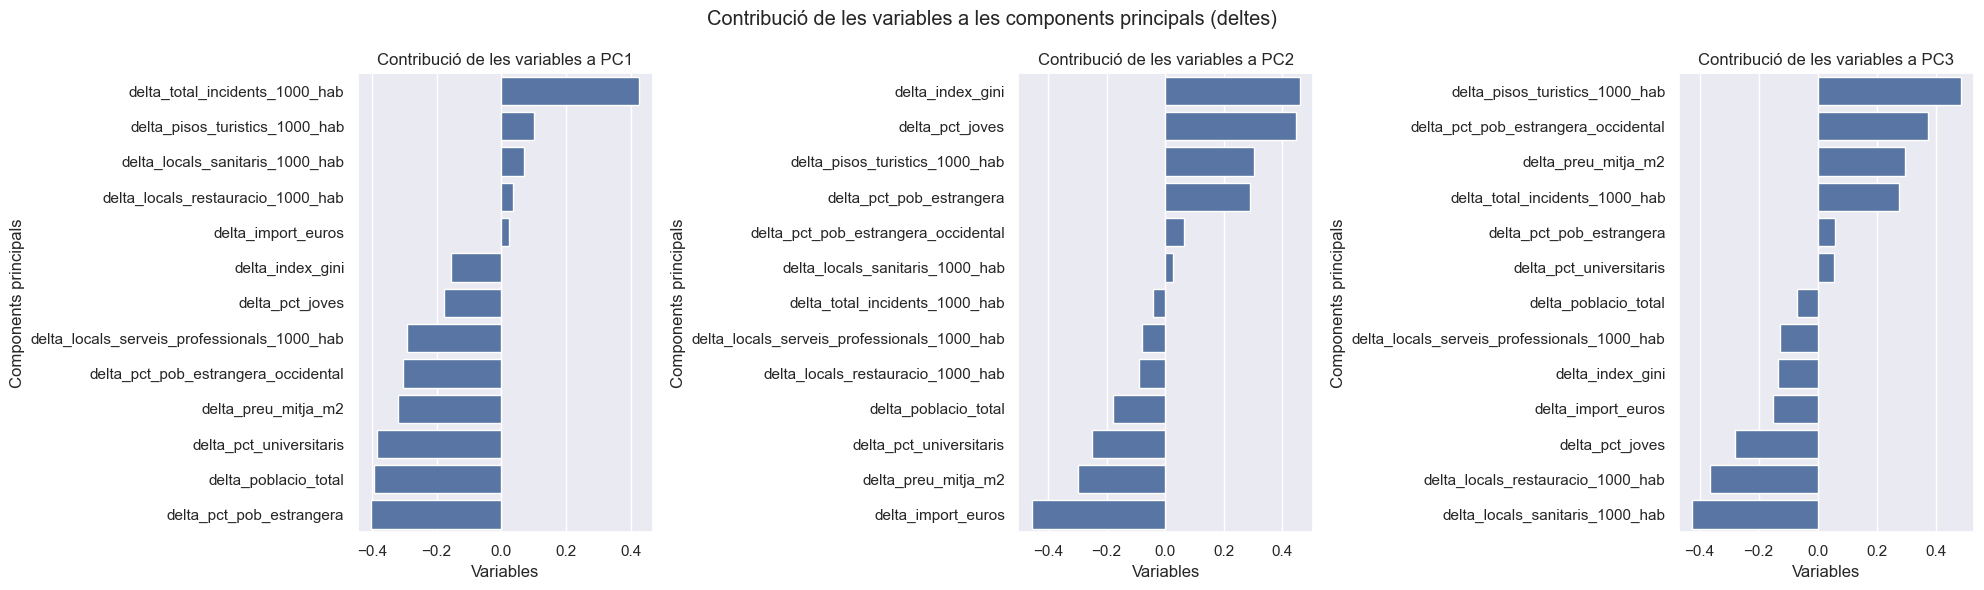

In [37]:
components_deltes = pd.DataFrame(pca_deltes_fixed.components_[0:3], columns=X_deltes.columns, index=["PC1", "PC2", "PC3"]).T.reset_index(names="atribut")


fig, axes = plt.subplots(figsize=(20, 6), nrows=1, ncols=3)
sns.barplot(data=components_deltes.sort_values("PC1", ascending=False), y="atribut", x="PC1",  ax=axes[0])
sns.barplot(data=components_deltes.sort_values("PC2", ascending=False), y="atribut", x="PC2", ax=axes[1])
sns.barplot(data=components_deltes.sort_values("PC3", ascending=False), y="atribut", x="PC3", ax=axes[2])
plt.suptitle("Contribució de les variables a les components principals (deltes)")
axes[0].set_title("Contribució de les variables a PC1")
axes[1].set_title("Contribució de les variables a PC2")
axes[2].set_title("Contribució de les variables a PC3")
axes[0].set_xlabel("Variables")
axes[1].set_xlabel("Variables")
axes[2].set_xlabel("Variables")
axes[0].set_ylabel("Components principals")
axes[1].set_ylabel("Components principals")
axes[2].set_ylabel("Components principals")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "contribucio_variables_pca_deltes.png")
plt.show()


## KMeans

In [33]:
# Comparem clusters amb pca vs dades escalades
resultats_deltes = {}
resultats_deltes["pca"] = evaluate_kmeans(X_pca_deltes_fixed, MIN, MAX)
resultats_deltes["escalades"] = evaluate_kmeans(X_deltes_scaled, MIN, MAX)
resultats_deltes["n_clusters"] = range(MIN, MAX)

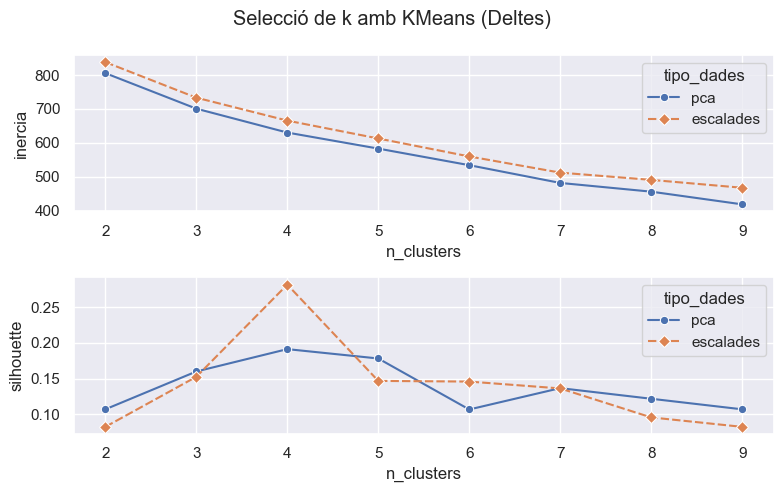

In [34]:
plot_seleccio_kmeans(resultats_deltes, "Deltes", "seleccio_k_deltes.png")

**Observacions:**
- En aquest cas, les dades escalades obtenen un major nivell coeficient de silhouette. No obstant, no els resultats no presenten una separació dels barris de gaire qualitat.

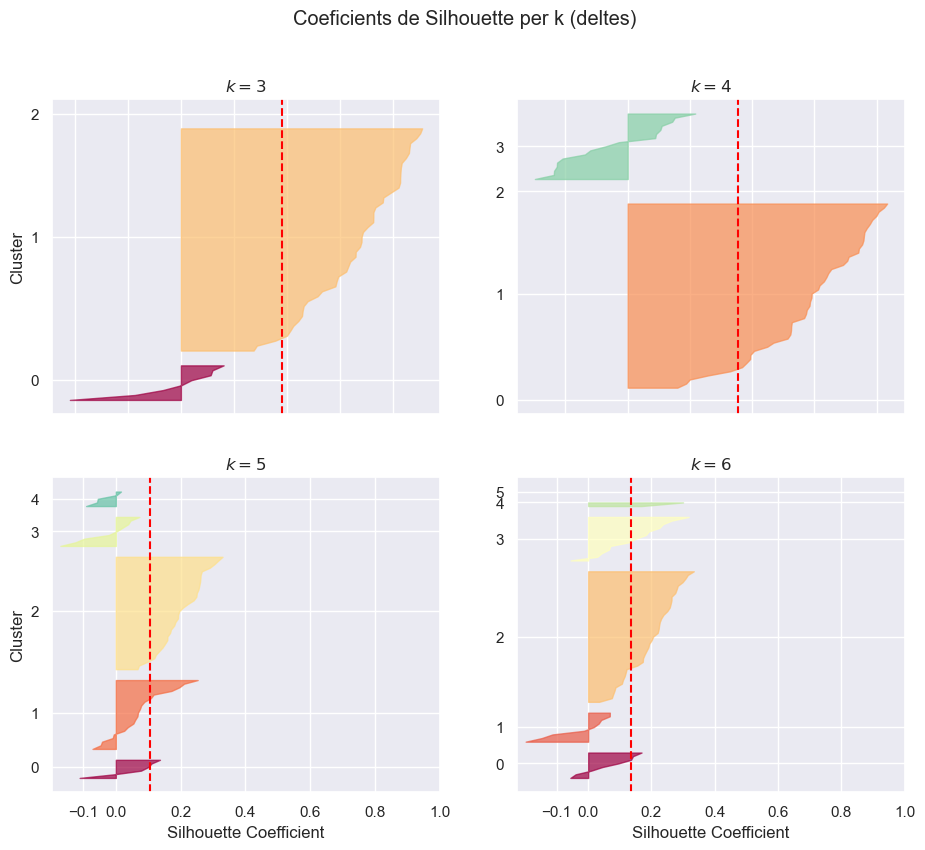

In [35]:
plot_silhouettes(resultats_deltes["pca"]["models"], resultats_deltes["pca"]["silhouettes"], X_pca_deltes_fixed, "deltes", "silhouettes_deltes_pca.png")

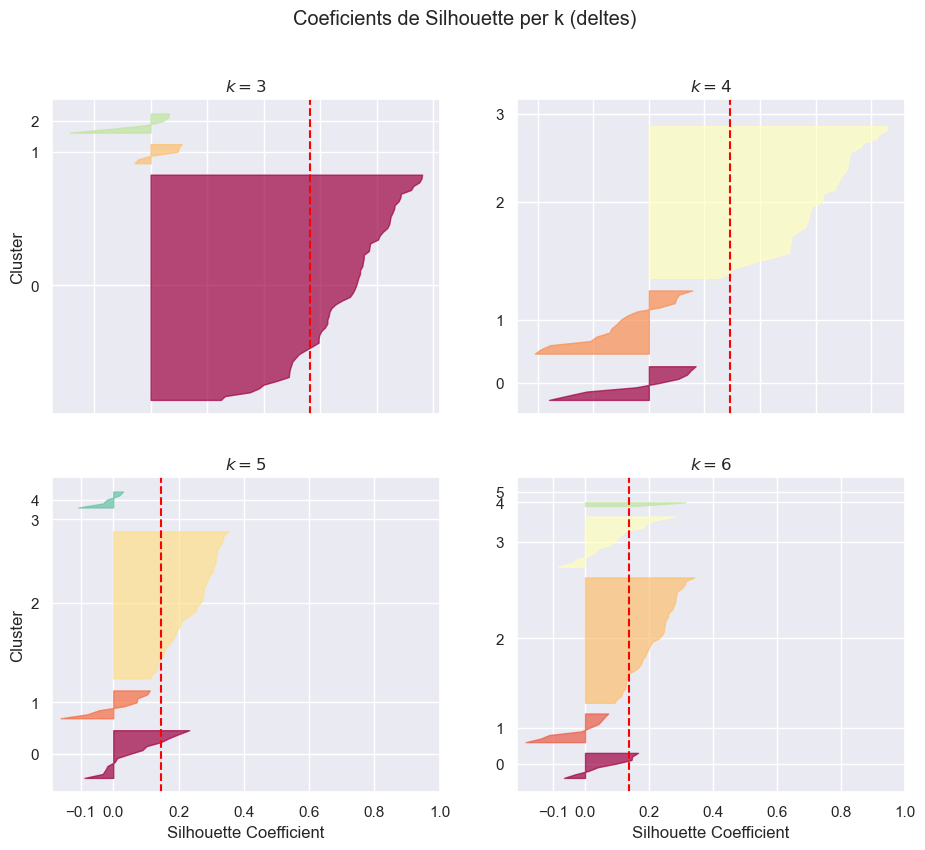

In [36]:
plot_silhouettes(resultats_deltes["escalades"]["models"], resultats_deltes["escalades"]["silhouettes"], X_deltes_scaled, "deltes", "silhouettes_deltes_scaled.png")

**Observacions: **
- Tant per les dades escalades com per les dades amb pca aplicat, s'observa unm cluster dominant i els altres més residuals. 
- En ambdós casos, com hem vist abans k=4 és el que obté un valor més alt. No obstant, per simplicitat i interpretabilitat seleccionarem k=3, on hi ha un grup dominant i dos clusters més residuals / extrems.

## Decisió i conclusions

In [37]:
conclusions_deltes = {"clusters": "k=3", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "En ambdós casos, com hem vist abans k=4 és el que obté un valor més alt. No obstant, per simplicitat i interpretabilitat seleccionarem k=3, on hi ha un grup dominant i dos clusters més residuals / extrems. Mantenim amb PCA per homogeneïtat."}

df_to_markdown(pd.DataFrame([conclusions_deltes]))

## Clustering

In [38]:
# Apliquem kmeans
k_deltes = 3
kmeans_deltes_final = KMeans(n_clusters= k_deltes, random_state= 42, n_init = 20)
kmeans_deltes_final_labels = kmeans_deltes_final.fit_predict(X_pca_deltes_fixed)

# Obtenim codi de barri i cluster
clustered_deltes = df_deltes[["codi_barri"]].copy()
clustered_deltes['cluster'] = kmeans_deltes_final_labels
clustered_deltes.head()


,codi_barri,cluster
0,1,2
1,2,0
2,3,2
3,4,2
4,5,0


In [39]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered_deltes["cluster"].value_counts() )
print("\nPerfils: ")
perfils_deltes = df_deltes.merge(clustered_deltes, on = "codi_barri", how = "right")
perfils_deltes.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
0    48
2    24
1     1
Name: count, dtype: int64

Perfils: 


cluster,0,1,2
codi_barri,37.208333,12.000000,37.625000
delta_pct_pob_estrangera,0.565607,0.985491,0.289770
delta_pct_pob_estrangera_occidental,0.363137,3.423398,0.209883
delta_pct_joves,0.013901,-0.034585,-0.052909
delta_pct_universitaris,0.272532,2.179257,0.290271
delta_poblacio_total,0.055100,0.495544,0.028993
delta_import_euros,0.294933,0.568477,0.361119
delta_index_gini,-0.051502,0.000000,-0.084865
delta_total_incidents_1000_hab,0.113729,-0.249872,0.164951
delta_locals_restauracio_1000_hab,-0.014132,0.050741,0.201675


In [40]:
barris_clusters_deltes = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_deltes_merged = barris_clusters_deltes.merge(clustered_deltes, on = "codi_barri", how = "left")

for c in set(barris_clusters_deltes_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_deltes_merged["nom_barri"][barris_clusters_deltes_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['el Barri Gòtic' 'el Fort Pienc' 'la Sagrada Família'
 "la Dreta de l'Eixample" "l'Antiga Esquerra de l'Eixample"
 "la Nova Esquerra de l'Eixample" 'la Marina de Port'
 'la Font de la Guatlla' 'la Bordeta' 'Sants' 'les Corts'
 'la Maternitat i Sant Ramon' 'Pedralbes' 'Sant Gervasi - la Bonanova'
 'Sant Gervasi - Galvany' 'el Putxet i el Farró'
 'Vallcarca i els Penitents' 'el Coll' 'la Salut'
 "el Camp d'en Grassot i Gràcia Nova" 'el Baix Guinardó' 'Can Baró'
 'el Guinardó' "la Font d'en Fargues" 'el Carmel' 'la Teixonera'
 'Sant Genís dels Agudells' 'Montbau' "la Vall d'Hebron" 'Horta'
 'Vilapicina i la Torre Llobeta' 'Porta' 'el Turó de la Peira'
 'la Guineueta' 'Canyelles' 'Verdun' 'la Prosperitat' 'el Bon Pastor'
 'Sant Andreu' 'la Sagrera' 'el Congrés i els Indians' 'Navas'
 "el Camp de l'Arpa del Clot" 'el Clot' 'el Besòs i el Maresme'
 'Provençals del Poblenou' 'Sant Martí de Provençals'
 'la Verneda i la Pau']
*********************************************

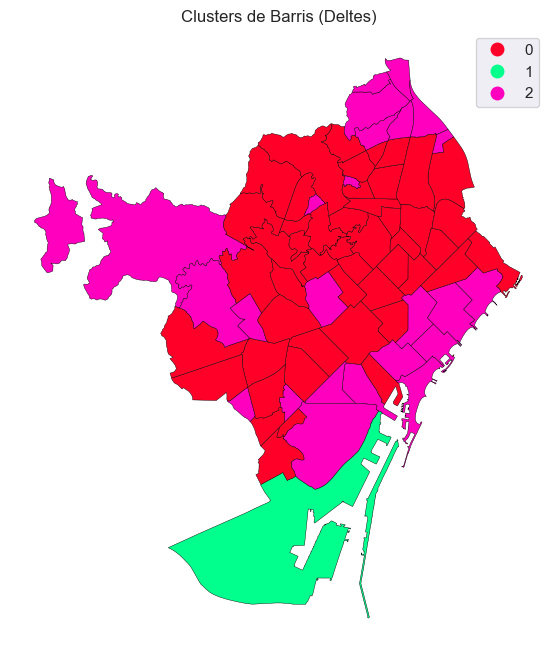

In [191]:

plot_clusters(clustered_deltes, "Clusters de Barris (Deltes)", "clusters_deltes.png")

In [192]:
df_to_markdown(perfils_deltes.groupby("cluster").mean().T)

In [193]:
perfils_deltes.to_csv(DATA_DIR / 'clustered' / 'df_deltes.csv', index= False)